In [1]:

%pip install pandas numpy scikit-learn matplotlib seaborn xgboost lightgbm joblib --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
!python -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, joblib
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve)
import xgboost as xgb
import lightgbm as lgb

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
COLUMNS = [
    "duration","protocol_type","service","flag",
    "src_bytes","dst_bytes","land","wrong_fragment","urgent",
    "hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

# ⚠️  Update these paths to wherever your files are located
TRAIN_PATH = r"C:\Users\aksha\Downloads\archive\train_csv.txt"
TEST_PATH  = r"C:\Users\aksha\Downloads\archive\test_csv.txt"


train_df = pd.read_csv(TRAIN_PATH, header=None, names=COLUMNS)
test_df  = pd.read_csv(TEST_PATH,  header=None, names=COLUMNS)

print(f"Train shape : {train_df.shape}")
print(f"Test  shape : {test_df.shape}")
train_df.head()

Train shape : (125973, 43)
Test  shape : (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


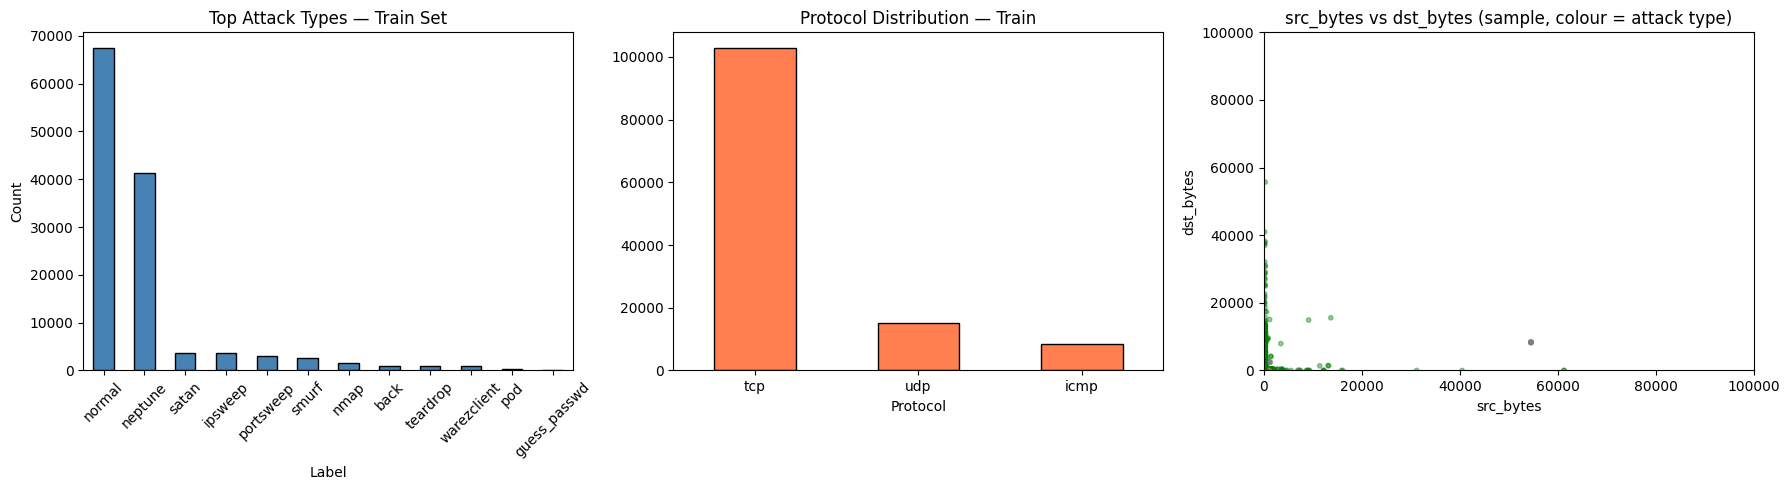


Unique labels in Train : 23
Unique labels in Test  : 38
Novel attack types in Test (unseen in train): {'xlock', 'udpstorm', 'saint', 'sqlattack', 'named', 'snmpguess', 'ps', 'snmpgetattack', 'xsnoop', 'xterm', 'processtable', 'mailbomb', 'apache2', 'sendmail', 'mscan', 'worm', 'httptunnel'}


In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Attack type distribution (train)
label_counts = train_df["label"].value_counts().head(12)
label_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Top Attack Types — Train Set")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Protocol distribution
train_df["protocol_type"].value_counts().plot(kind="bar", ax=axes[1],
                                               color="coral", edgecolor="black")
axes[1].set_title("Protocol Distribution — Train")
axes[1].set_xlabel("Protocol")
axes[1].tick_params(axis="x", rotation=0)

# src_bytes vs dst_bytes scatter (sample 2000)
sample = train_df.sample(2000, random_state=42)
colors_map = {"normal": "green", "neptune": "red", "smurf": "orange",
              "ipsweep": "purple", "portsweep": "blue"}
sample["plot_color"] = sample["label"].map(lambda x: colors_map.get(x, "gray"))
axes[2].scatter(sample["src_bytes"], sample["dst_bytes"],
                c=sample["plot_color"], alpha=0.4, s=10)
axes[2].set_title("src_bytes vs dst_bytes (sample, colour = attack type)")
axes[2].set_xlabel("src_bytes")
axes[2].set_ylabel("dst_bytes")
axes[2].set_xlim(0, 100000)
axes[2].set_ylim(0, 100000)

plt.tight_layout()
plt.show()

print(f"\nUnique labels in Train : {train_df['label'].nunique()}")
print(f"Unique labels in Test  : {test_df['label'].nunique()}")
novel = set(test_df['label'].unique()) - set(train_df['label'].unique())
print(f"Novel attack types in Test (unseen in train): {novel}")

In [6]:
train_df["binary_label"] = (train_df["label"] != "normal").astype(int)
test_df["binary_label"]  = (test_df["label"]  != "normal").astype(int)

# Encode categorical columns
cat_cols = ["protocol_type", "service", "flag"]
for col in cat_cols:
    le_cat = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]])
    le_cat.fit(combined)
    train_df[col] = le_cat.transform(train_df[col])
    test_df[col]  = le_cat.transform(test_df[col])

# Feature / target split
DROP = ["label", "binary_label", "difficulty"]
FEATURE_COLS = [c for c in COLUMNS if c not in DROP]

X_train = train_df[FEATURE_COLS].values
y_train = train_df["binary_label"].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df["binary_label"].values

# Scale (needed for some models)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Features    : {len(FEATURE_COLS)}")
print(f"Train size  : {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")
print(f"Train — Normal: {(y_train==0).sum():,}   Attack: {(y_train==1).sum():,}")
print(f"Test  — Normal: {(y_test==0).sum():,}    Attack: {(y_test==1).sum():,}")


Features    : 41
Train size  : 125,973  |  Test size: 22,544
Train — Normal: 67,343   Attack: 58,630
Test  — Normal: 9,711    Attack: 12,833


In [7]:
t0 = time.time()
rf = RandomForestClassifier(n_estimators=200, max_depth=25,
                             min_samples_leaf=2, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rf_time = time.time() - t0

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print(f"Random Forest trained in {rf_time:.1f}s")
print(f"Accuracy : {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"F1 Score : {f1_score(y_test, rf_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, rf_prob):.4f}")

Random Forest trained in 4.0s
Accuracy : 77.24%
F1 Score : 0.7565
AUC-ROC  : 0.9689


In [8]:
t0 = time.time()
et = ExtraTreesClassifier(n_estimators=200, max_depth=25,
                           min_samples_leaf=2, n_jobs=-1, random_state=42)
et.fit(X_train, y_train)
et_time = time.time() - t0

et_pred = et.predict(X_test)
et_prob = et.predict_proba(X_test)[:, 1]

print(f"Extra Trees trained in {et_time:.1f}s")
print(f"Accuracy : {accuracy_score(y_test, et_pred)*100:.2f}%")
print(f"F1 Score : {f1_score(y_test, et_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, et_prob):.4f}")

Extra Trees trained in 3.3s
Accuracy : 77.27%
F1 Score : 0.7573
AUC-ROC  : 0.9599


In [9]:
t0 = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", tree_method="hist",
    n_jobs=-1, random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - t0

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print(f"XGBoost trained in {xgb_time:.1f}s")
print(f"Accuracy : {accuracy_score(y_test, xgb_pred)*100:.2f}%")
print(f"F1 Score : {f1_score(y_test, xgb_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, xgb_prob):.4f}")

XGBoost trained in 1.7s
Accuracy : 80.46%
F1 Score : 0.7983
AUC-ROC  : 0.9748


In [10]:
t0 = time.time()
lgb_model = lgb.LGBMClassifier(
    n_estimators=200, max_depth=10, learning_rate=0.1,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=42, verbose=-1
)
lgb_model.fit(X_train, y_train)
lgb_time = time.time() - t0

lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]

print(f"LightGBM trained in {lgb_time:.1f}s")
print(f"Accuracy : {accuracy_score(y_test, lgb_pred)*100:.2f}%")
print(f"F1 Score : {f1_score(y_test, lgb_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, lgb_prob):.4f}")


LightGBM trained in 1.5s
Accuracy : 77.33%
F1 Score : 0.7580
AUC-ROC  : 0.9748


In [11]:
t0 = time.time()
ensemble = VotingClassifier(
    estimators=[
        ("rf",  rf),
        ("et",  et),
        ("xgb", xgb_model),
        ("lgb", lgb_model)
    ],
    voting="soft",  # uses predicted probabilities, not just votes
    n_jobs=-1
)
ensemble.fit(X_train, y_train)
ens_time = time.time() - t0

ens_pred = ensemble.predict(X_test)
ens_prob = ensemble.predict_proba(X_test)[:, 1]

print(f"Voting Ensemble trained in {ens_time:.1f}s")
print(f"Accuracy : {accuracy_score(y_test, ens_pred)*100:.2f}%")
print(f"F1 Score : {f1_score(y_test, ens_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, ens_prob):.4f}")

Voting Ensemble trained in 13.6s
Accuracy : 78.74%
F1 Score : 0.7764
AUC-ROC  : 0.9671


In [12]:
models = {
    "Random Forest" : (rf_pred,  rf_prob,  rf_time),
    "Extra Trees"   : (et_pred,  et_prob,  et_time),
    "XGBoost"       : (xgb_pred, xgb_prob, xgb_time),
    "LightGBM"      : (lgb_pred, lgb_prob, lgb_time),
    "Ensemble"      : (ens_pred, ens_prob, ens_time),
}

print(f"{'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC-ROC':>10} {'Time':>8}")
print("-" * 80)
for name, (pred, prob, t) in models.items():
    acc  = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec  = recall_score(y_test, pred, zero_division=0)
    f1   = f1_score(y_test, pred, zero_division=0)
    auc  = roc_auc_score(y_test, prob)
    print(f"{name:<20} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {auc:>10.4f} {t:>6.1f}s")
    

Model                  Accuracy  Precision     Recall         F1    AUC-ROC     Time
--------------------------------------------------------------------------------
Random Forest            0.7724     0.9672     0.6212     0.7565     0.9689    4.0s
Extra Trees              0.7727     0.9655     0.6230     0.7573     0.9599    3.3s
XGBoost                  0.8046     0.9682     0.6791     0.7983     0.9748    1.7s
LightGBM                 0.7733     0.9660     0.6238     0.7580     0.9748    1.5s
Ensemble                 0.7874     0.9673     0.6484     0.7764     0.9671   13.6s


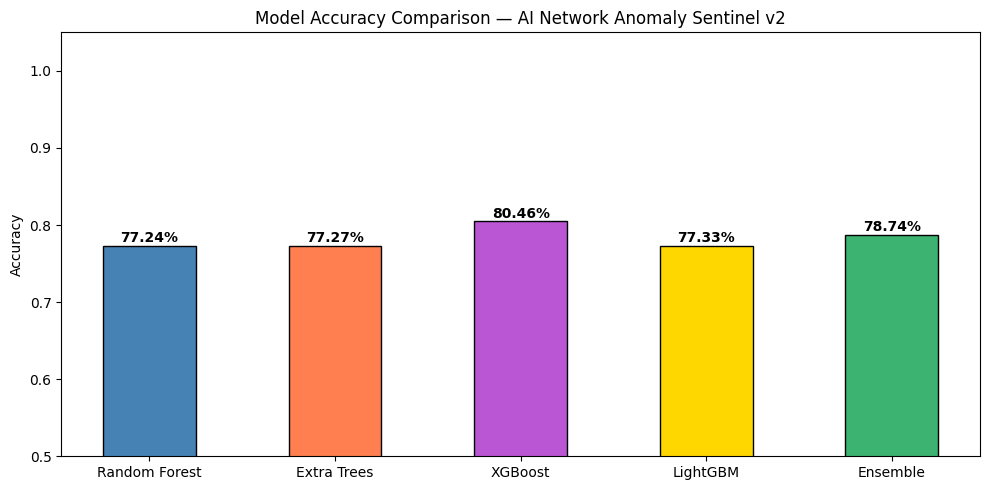

In [13]:
model_names   = list(models.keys())
accuracies    = [accuracy_score(y_test, models[m][0]) for m in model_names]
colors        = ["steelblue", "coral", "mediumorchid", "gold", "mediumseagreen"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(model_names, accuracies, color=colors, edgecolor="black", width=0.5)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy Comparison — AI Network Anomaly Sentinel v2")
for bar, v in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
            f"{v*100:.2f}%", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

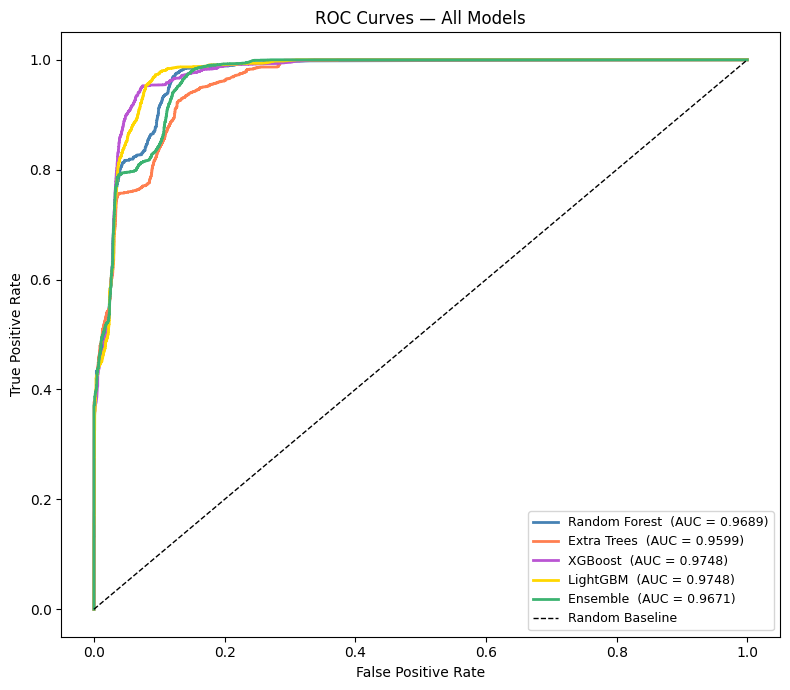

In [14]:
line_colors = ["steelblue", "coral", "mediumorchid", "gold", "mediumseagreen"]

fig, ax = plt.subplots(figsize=(8, 7))
for (name, (pred, prob, _)), color in zip(models.items(), line_colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name}  (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

In [15]:
tuned_results = {}

for name, (pred, prob, t) in models.items():
    fpr, tpr, thresholds = roc_curve(y_test, prob)
    j_scores   = tpr - fpr
    best_idx   = np.argmax(j_scores)
    best_thresh = thresholds[best_idx]

    tuned_pred = (prob >= best_thresh).astype(int)
    acc  = accuracy_score(y_test, tuned_pred)
    prec = precision_score(y_test, tuned_pred, zero_division=0)
    rec  = recall_score(y_test, tuned_pred, zero_division=0)
    f1   = f1_score(y_test, tuned_pred, zero_division=0)
    auc  = roc_auc_score(y_test, prob)

    tuned_results[name] = {
        "pred": tuned_pred, "prob": prob, "thresh": best_thresh,
        "acc": acc, "prec": prec, "rec": rec, "f1": f1, "auc": auc
    }

print(f"{'Model':<20} {'Threshold':>10} {'Accuracy':>10} {'F1':>10} {'AUC':>10}")
print("-" * 62)
for name, r in tuned_results.items():
    print(f"{name:<20} {r['thresh']:>10.3f} {r['acc']:>10.4f} {r['f1']:>10.4f} {r['auc']:>10.4f}")

Model                 Threshold   Accuracy         F1        AUC
--------------------------------------------------------------
Random Forest             0.023     0.9319     0.9422     0.9689
Extra Trees               0.028     0.9018     0.9148     0.9599
XGBoost                   0.001     0.9409     0.9483     0.9748
LightGBM                  0.000     0.9440     0.9519     0.9748
Ensemble                  0.007     0.9244     0.9367     0.9671


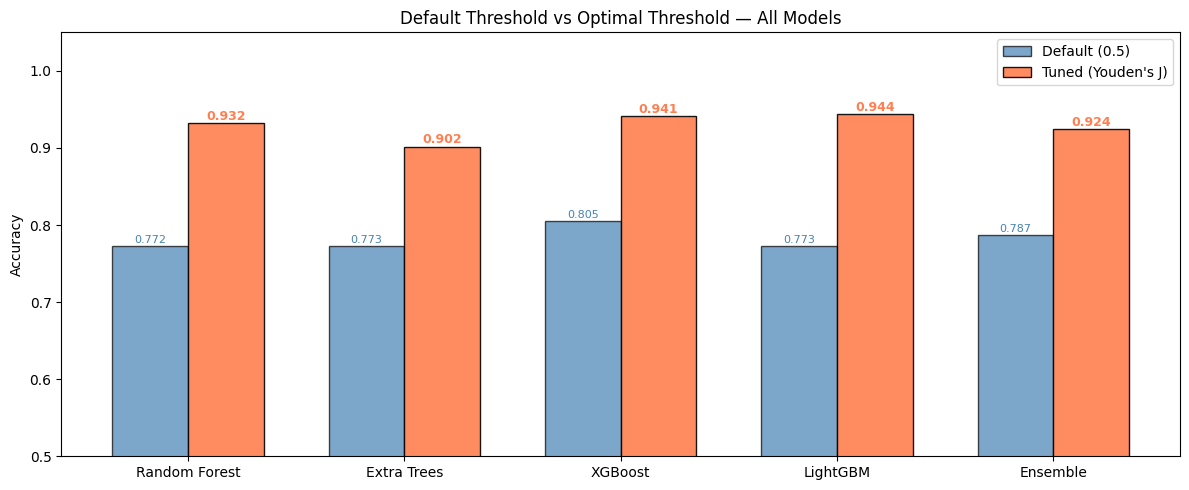

In [16]:
names_list   = list(models.keys())
default_accs = [accuracy_score(y_test, models[m][0]) for m in names_list]
tuned_accs   = [tuned_results[m]["acc"] for m in names_list]

x     = np.arange(len(names_list))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - width/2, default_accs, width, label="Default (0.5)",
            color="steelblue", alpha=0.7, edgecolor="black")
b2 = ax.bar(x + width/2, tuned_accs,   width, label="Tuned (Youden's J)",
            color="coral", alpha=0.9, edgecolor="black")

ax.set_xticks(x)
ax.set_xticklabels(names_list, fontsize=10)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Default Threshold vs Optimal Threshold — All Models")
ax.legend()

for bar, v in zip(b1, default_accs):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.004, f"{v:.3f}",
            ha="center", fontsize=8, color="steelblue")
for bar, v in zip(b2, tuned_accs):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.004, f"{v:.3f}",
            ha="center", fontsize=9, fontweight="bold", color="coral")

plt.tight_layout()
plt.show()

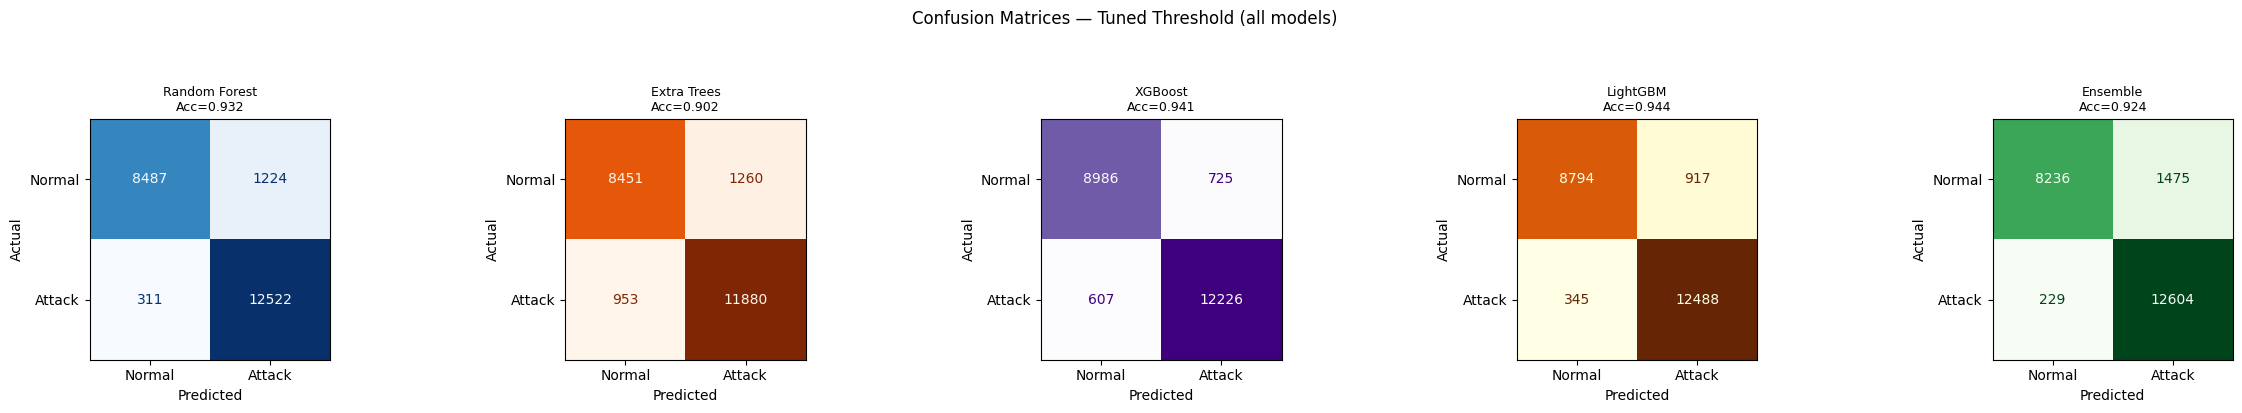

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(24, 4))
cmaps = ["Blues", "Oranges", "Purples", "YlOrBr", "Greens"]

for ax, (name, r), cmap in zip(axes, tuned_results.items(), cmaps):
    cm = confusion_matrix(y_test, r["pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Normal", "Attack"])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f"{name}\nAcc={r['acc']:.3f}", fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Tuned Threshold (all models)", fontsize=12, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])

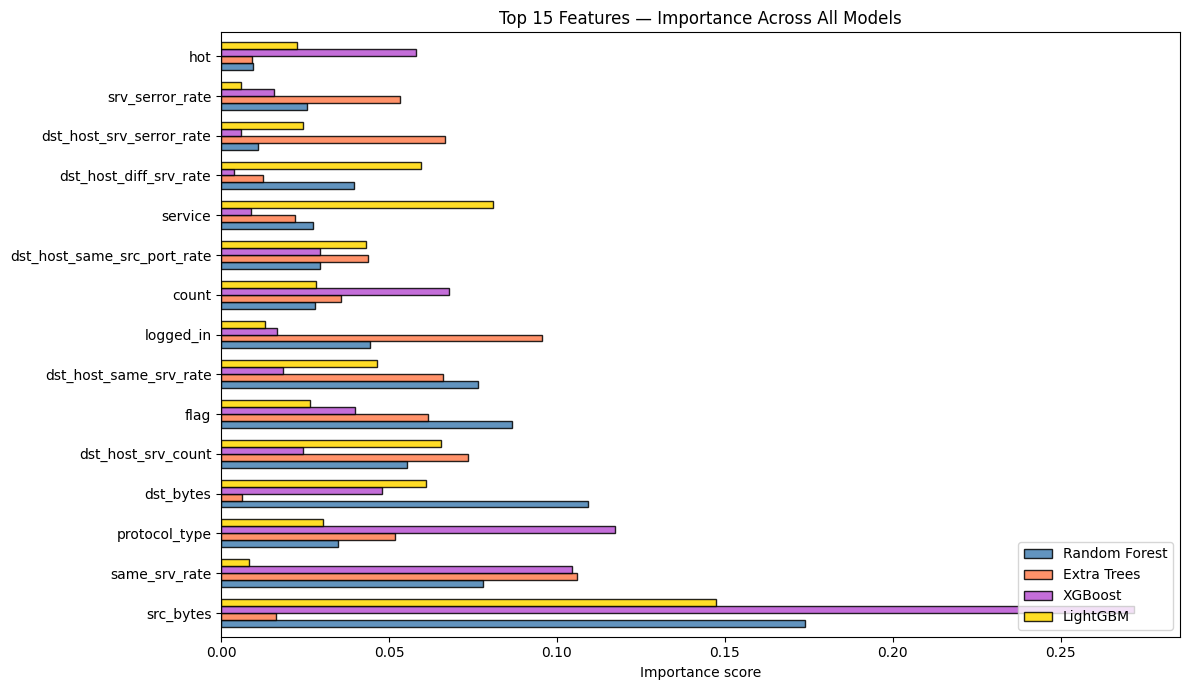

In [20]:
fi_rf  = pd.Series(rf.feature_importances_,        index=FEATURE_COLS)
fi_et  = pd.Series(et.feature_importances_,        index=FEATURE_COLS)
fi_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
fi_lgb = pd.Series(lgb_model.feature_importances_, index=FEATURE_COLS)

# Normalise LGB (returns raw counts, not fractions)
fi_lgb = fi_lgb / fi_lgb.sum()

# Top 15 by average importance
top15 = (fi_rf + fi_et + fi_xgb + fi_lgb).sort_values(ascending=False).head(15).index

df_fi = pd.DataFrame({
    "Random Forest": fi_rf[top15],
    "Extra Trees"  : fi_et[top15],
    "XGBoost"      : fi_xgb[top15],
    "LightGBM"     : fi_lgb[top15],
}, index=top15)

df_fi.plot(kind="barh", figsize=(12, 7), width=0.7,
           color=["steelblue", "coral", "mediumorchid", "gold"],
           edgecolor="black", alpha=0.85)
plt.title("Top 15 Features — Importance Across All Models")
plt.xlabel("Importance score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

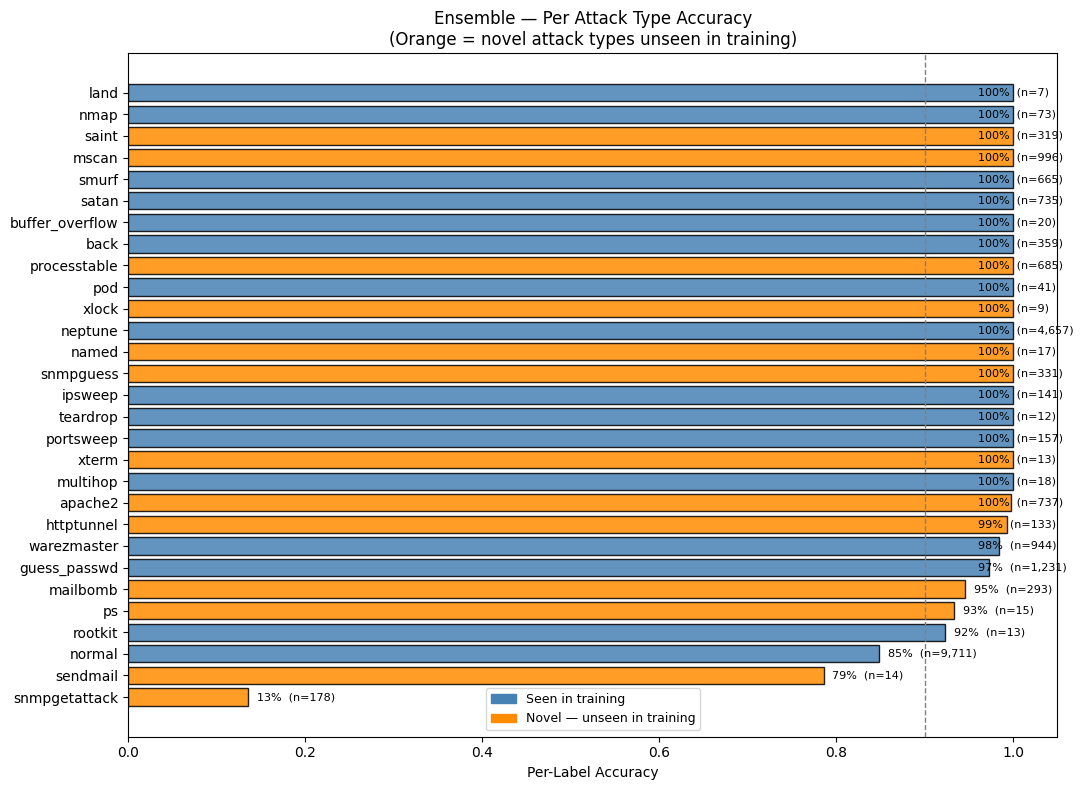


Novel attack types: ['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']


In [22]:
all_labels = test_df["label"].values
novel_set  = set(test_df["label"].unique()) - set(train_df["label"].unique())

label_acc = {}
for lbl in test_df["label"].unique():
    mask = all_labels == lbl
    if mask.sum() < 5:
        continue
    correct = (tuned_results["Ensemble"]["pred"][mask] == y_test[mask]).mean()
    label_acc[lbl] = {"acc": correct, "n": mask.sum(), "novel": lbl in novel_set}

la_df = pd.DataFrame(label_acc).T.sort_values("acc")
la_df["acc"] = la_df["acc"].astype(float)

bar_colors = ["darkorange" if novel else "steelblue" for novel in la_df["novel"]]
fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(la_df.index, la_df["acc"], color=bar_colors, edgecolor="black", alpha=0.85)
ax.set_xlabel("Per-Label Accuracy")
ax.set_title("""Ensemble — Per Attack Type Accuracy
(Orange = novel attack types unseen in training)""")
ax.axvline(0.9, color="gray", linestyle="--", lw=1)

for bar, (_, row) in zip(bars, la_df.iterrows()):
    w = bar.get_width()
    ax.text(min(w + 0.01, 0.96), bar.get_y() + bar.get_height()/2,
            f"{w:.0%}  (n={int(row['n']):,})", va="center", fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="steelblue",  label="Seen in training"),
    Patch(color="darkorange", label="Novel — unseen in training")
], fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nNovel attack types: {sorted(novel_set)}")

In [23]:
best_name = max(tuned_results, key=lambda n: tuned_results[n]["acc"])
best_pred = tuned_results[best_name]["pred"]

print(f"Best model: {best_name}  (Acc = {tuned_results[best_name]['acc']*100:.2f}%)")
print("=" * 55)
print(classification_report(y_test, best_pred, target_names=["Normal", "Attack"]))

Best model: LightGBM  (Acc = 94.40%)
              precision    recall  f1-score   support

      Normal       0.96      0.91      0.93      9711
      Attack       0.93      0.97      0.95     12833

    accuracy                           0.94     22544
   macro avg       0.95      0.94      0.94     22544
weighted avg       0.94      0.94      0.94     22544



In [24]:
def detect_anomaly(duration, src_bytes, dst_bytes, protocol_type,
                   service, flag, count, srv_count):
    """
    Classify a single network connection using all trained models.

    Parameters (main ones — rest default to 0):
    -----------
    duration       : length of connection in seconds
    src_bytes      : bytes sent from source
    dst_bytes      : bytes sent to destination
    protocol_type  : 0=icmp, 1=tcp, 2=udp  (encoded)
    service        : encoded service id (0-65)
    flag           : encoded connection flag (0-10)
    count          : connections to same host in last 2s
    srv_count      : connections to same service in last 2s
    """
    # Build a zero-filled feature vector, then fill in the known ones
    row = np.zeros(len(FEATURE_COLS))
    feature_map = {
        "duration": duration, "protocol_type": protocol_type,
        "service": service, "flag": flag, "src_bytes": src_bytes,
        "dst_bytes": dst_bytes, "count": count, "srv_count": srv_count
    }
    for feat, val in feature_map.items():
        if feat in FEATURE_COLS:
            row[FEATURE_COLS.index(feat)] = val

    row_2d = row.reshape(1, -1)
    row_s  = scaler.transform(row_2d)

    all_models = {
        "Random Forest" : rf,
        "Extra Trees"   : et,
        "XGBoost"       : xgb_model,
        "LightGBM"      : lgb_model,
        "Ensemble"      : ensemble,
    }
    thresholds = {n: tuned_results[n]["thresh"] for n in all_models}

    votes = []
    print("─" * 45)
    for name, model in all_models.items():
        prob   = model.predict_proba(row_2d)[0][1]
        thresh = thresholds[name]
        label  = "🔴 ATTACK" if prob >= thresh else "🟢 Normal"
        votes.append(1 if prob >= thresh else 0)
        print(f"  {name:<18}  prob={prob:.3f}  →  {label}")

    print("─" * 45)
    verdict = "🚨 THREAT DETECTED" if sum(votes) >= 3 else "✅ Traffic Normal"
    print(f"  Consensus ({sum(votes)}/5 flagged)  →  {verdict}")
    print("─" * 45)

# ─── Test 1: Normal web browsing ───────────────────────────────
print("TEST 1 — Normal web browsing (TCP, HTTP, SF flag):")
detect_anomaly(duration=0, src_bytes=491, dst_bytes=0,
               protocol_type=1, service=10, flag=9,
               count=2, srv_count=2)

# ─── Test 2: Neptune (SYN flood / DoS) ─────────────────────────
print("\nTEST 2 — Neptune DoS attack (many connections, no response):")
detect_anomaly(duration=0, src_bytes=0, dst_bytes=0,
               protocol_type=1, service=40, flag=5,
               count=511, srv_count=511)

# ─── Test 3: Port scan (many unique ports, tiny bytes) ─────────
print("\nTEST 3 — Port scan (ipsweep pattern):")
detect_anomaly(duration=0, src_bytes=28, dst_bytes=0,
               protocol_type=0, service=49, flag=1,
               count=511, srv_count=20)

TEST 1 — Normal web browsing (TCP, HTTP, SF flag):
─────────────────────────────────────────────
  Random Forest       prob=0.129  →  🔴 ATTACK
  Extra Trees         prob=0.187  →  🔴 ATTACK
  XGBoost             prob=0.001  →  🔴 ATTACK
  LightGBM            prob=0.000  →  🟢 Normal
  Ensemble            prob=0.079  →  🔴 ATTACK
─────────────────────────────────────────────
  Consensus (4/5 flagged)  →  🚨 THREAT DETECTED
─────────────────────────────────────────────

TEST 2 — Neptune DoS attack (many connections, no response):
─────────────────────────────────────────────
  Random Forest       prob=0.557  →  🔴 ATTACK
  Extra Trees         prob=0.589  →  🔴 ATTACK
  XGBoost             prob=0.995  →  🔴 ATTACK
  LightGBM            prob=0.972  →  🔴 ATTACK
  Ensemble            prob=0.778  →  🔴 ATTACK
─────────────────────────────────────────────
  Consensus (5/5 flagged)  →  🚨 THREAT DETECTED
─────────────────────────────────────────────

TEST 3 — Port scan (ipsweep pattern):
────────────────

In [25]:
joblib.dump(rf,        "model_rf.pkl")
joblib.dump(et,        "model_et.pkl")
joblib.dump(xgb_model, "model_xgb.pkl")
joblib.dump(lgb_model, "model_lgb.pkl")
joblib.dump(ensemble,  "model_ensemble.pkl")
joblib.dump(scaler,    "scaler.pkl")

import json
json.dump({k: float(v["thresh"]) for k, v in tuned_results.items()},
          open("optimal_thresholds.json", "w"), indent=2)

print("All models saved:")
print("  model_rf.pkl · model_et.pkl · model_xgb.pkl · model_lgb.pkl")
print("  model_ensemble.pkl · scaler.pkl · optimal_thresholds.json")

All models saved:
  model_rf.pkl · model_et.pkl · model_xgb.pkl · model_lgb.pkl
  model_ensemble.pkl · scaler.pkl · optimal_thresholds.json


In [26]:
print("=" * 70)
print("  FINAL RESULTS — AI NETWORK ANOMALY SENTINEL v2 (TUNED THRESHOLD)")
print("=" * 70)
print(f"  {'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10}")
print("-" * 70)
for name, r in tuned_results.items():
    marker = "  ← BEST" if name == max(tuned_results, key=lambda n: tuned_results[n]['acc']) else ""
    print(f"  {name:<20} {r['acc']:>10.4f} {r['prec']:>10.4f} {r['rec']:>10.4f} {r['f1']:>10.4f} {r['auc']:>10.4f}{marker}")
print("=" * 70)
best = max(tuned_results, key=lambda n: tuned_results[n]["acc"])
print(f"\n  🏆  Best overall model : {best}")
print(f"  ✅  Best accuracy      : {tuned_results[best]['acc']*100:.2f}%")
print(f"  ✅  Best AUC-ROC       : {tuned_results[best]['auc']:.4f}")


  FINAL RESULTS — AI NETWORK ANOMALY SENTINEL v2 (TUNED THRESHOLD)
  Model                  Accuracy  Precision     Recall         F1        AUC
----------------------------------------------------------------------
  Random Forest            0.9319     0.9110     0.9758     0.9422     0.9689
  Extra Trees              0.9018     0.9041     0.9257     0.9148     0.9599
  XGBoost                  0.9409     0.9440     0.9527     0.9483     0.9748
  LightGBM                 0.9440     0.9316     0.9731     0.9519     0.9748  ← BEST
  Ensemble                 0.9244     0.8952     0.9822     0.9367     0.9671

  🏆  Best overall model : LightGBM
  ✅  Best accuracy      : 94.40%
  ✅  Best AUC-ROC       : 0.9748
